## FinLora Fraud Detection — Feature Engineering & Selection

This notebook continues from the EDA phase, translating the patterns uncovered there into model-ready features. Key findings guiding this work:

- Fraud compounds sharply when multiple "unfamiliarity" signals combine (new device, new account, low trust, location mismatch, chargeback history, low KYC)
- Fraud risk peaks non-linearly around $500-1,800 in transaction amount
- FinLora's internal risk score works well at the extremes but is ambiguous in the "Medium" range

### Importing Libraries

In [51]:
! pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.3 MB 974.6 kB/s eta 0:00:11
   --- ------------------------------------ 1.0/11.3 MB 980.2 kB/s eta 0:00:11
   --- ------------------------------------ 1.0/11.3 MB 980.2 kB/s eta 0:00:11
   ---- ----------------------------------- 1.3/11.3 MB 960.6 kB/s eta 0:00:11
   ----- ---------------------------------- 1.6/11.3 MB 1.0 MB/s eta 0:00:10
   ------ --------------------------------- 1.8/11.3 MB 1.1 MB/s eta 0:00:09
   ------- -------------------------------- 2.1/11.3 MB 1.1 MB/s eta 0:00:09
   -------- ------------------------------- 2.4/11.3 MB 1.1 MB/s eta 0:00:09
   --------- ------------------------------ 2.6/11.3 MB 1.1 MB/s eta 0:00:08
   ---------- -----


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Selection & Preprocessing 
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

### Load Dataset

In [118]:
df_EDA_transaction_data = pd.read_parquet(r"C:\Users\leest\OneDrive\Data Projects\Amdari Projects\Digital_Transfer_Fraud_Detection_System\Datasets\Artifats\FE_dataset")

### Initial Checks

In [119]:
df_EDA_transaction_data.shape

(10940, 39)

In [120]:
df_EDA_transaction_data.head(2).T

,0,1
transaction_id,fee8542d-8ee6-4b0d-9671-c294dd08ed26,bfdb9fc1-27fe-4a85-b043-4d813d679259
customer_id,402cccc9-28de-45b3-9af7-cc5302aa1f93,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad
timestamp,2022-10-03 18:40:59.468549+00:00,2022-10-03 20:39:38.468549+00:00
home_country,US,CA
source_currency,USD,CAD
dest_currency,CAD,MXN
channel,atm,web
amount_src,278.19,208.51
amount_usd,278.19,154.29
fee,4.25,4.24


### Feature Engineering

In [121]:
# Replacing the "not captured" KYC tier with low

df_EDA_transaction_data["kyc_tier"] = df_EDA_transaction_data["kyc_tier"].replace("not_captured", "low")

In [122]:
# Check 
df_EDA_transaction_data["kyc_tier"].unique()

array(['standard', 'enhanced', 'low'], dtype=object)

In [123]:
# Creating new features based on EDA findings to serve as signals 

df_EDA_transaction_data["late_night_hours"] = ((df_EDA_transaction_data["txn_hour"] >= 3) & (df_EDA_transaction_data["txn_hour"] <= 8)
).astype(int)

df_EDA_transaction_data["amount_high"] = (df_EDA_transaction_data["amount_usd"] >= 500).astype(int)

df_EDA_transaction_data["critical_ip_risk"] = (df_EDA_transaction_data["ip_risk_score"] >= 0.60).astype(int)

df_EDA_transaction_data["critical_device_trust"] = (df_EDA_transaction_data["device_trust_score"] <= 0.30).astype(int)

df_EDA_transaction_data["new_account"] = (df_EDA_transaction_data["account_age_days"] <= 90).astype(int)

df_EDA_transaction_data["velocity_spike"] = (df_EDA_transaction_data["txn_velocity_1h"] >= 3).astype(int)

df_EDA_transaction_data["chargeback_flag"] = (df_EDA_transaction_data["chargeback_history_count"] > 0).astype(int)

df_EDA_transaction_data["low_kyc"] = (df_EDA_transaction_data["kyc_tier"] == "low").astype(int)

df_EDA_transaction_data["web_high_amount"] = ((df_EDA_transaction_data["channel"] == "web") & (df_EDA_transaction_data["amount_usd"] >= 1000) &
    (df_EDA_transaction_data["amount_usd"] <= 3000)).astype(int)

df_EDA_transaction_data[["late_night_hours", "amount_high", "critical_device_trust", "new_account", "critical_ip_risk", 
                         "velocity_spike", "chargeback_flag", "low_kyc", "web_high_amount"]]

,late_night_hours,amount_high,critical_device_trust,new_account,critical_ip_risk,velocity_spike,chargeback_flag,low_kyc,web_high_amount
0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
10935,0,0,0,0,0,0,0,0,0
10936,1,0,1,1,1,1,1,1,0
10937,1,0,1,1,1,1,1,1,0
10938,0,0,0,0,0,0,0,0,0


### Multicollinearity Check & Feature Selection

In [124]:
df_EDA_transaction_data.columns

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud', 'fee_usd',
       'fraud_label', 'currency_route', 'account_age_tier', 'ip_risk_tier',
       'device_trust_tier', 'txn_year', 'txn_hour', 'txn_day_of_week',
       'txn_month_name', 'internal_risk_tier', 'amount_range',
       'risk_flag_count', 'late_night_hours', 'amount_high',
       'critical_ip_risk', 'critical_device_trust', 'new_account',
       'velocity_spike', 'chargeback_flag', 'low_kyc', 'web_high_amount'],
      dtype='object')

In [125]:
# Drop temporary EDA columns
df_EDA_transaction_data= df_EDA_transaction_data.drop(["fraud_label", "currency_route", "account_age_tier", "ip_risk_tier", "device_trust_tier", "internal_risk_tier",
                              "txn_month_name","txn_year", "amount_range", "risk_flag_count"], axis=1)

# Drop other irrelevant columns
df_EDA_transaction_data= df_EDA_transaction_data.drop(["transaction_id", "customer_id", "amount_src", "fee","fee_usd", "exchange_rate_src_to_dest", "device_id", "ip_address"], axis=1)

# Drop other columns due to multicollinearity 
df_EDA_transaction_data= df_EDA_transaction_data.drop(["txn_velocity_1h", "chargeback_history_count"], axis=1)

In [126]:
# df_EDA_transaction_data.columns

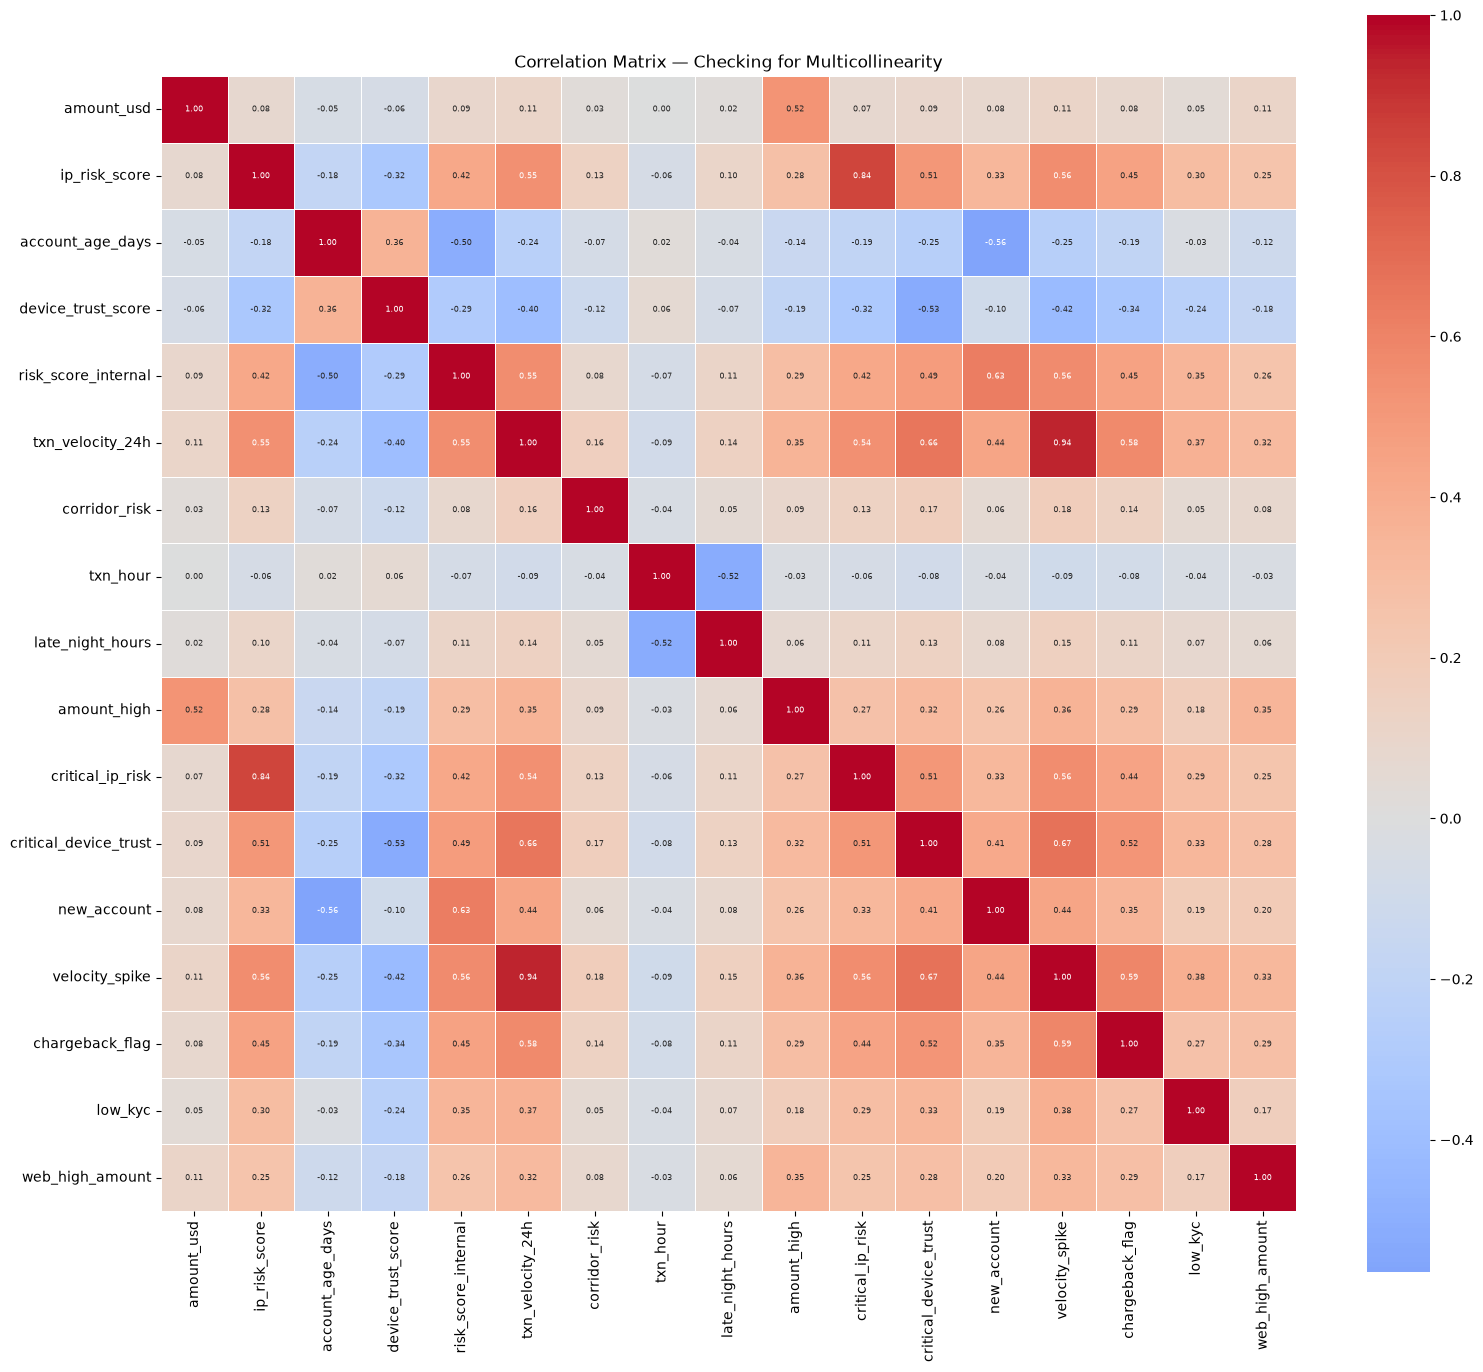

In [127]:
# Correlation Check

numeric_cols = [
    "amount_usd", "ip_risk_score", "account_age_days", "device_trust_score", "risk_score_internal", "txn_velocity_24h","corridor_risk", "txn_hour",
    "late_night_hours", "amount_high", "critical_ip_risk", "critical_device_trust","new_account", "velocity_spike", "chargeback_flag", "low_kyc", "web_high_amount"
]

corr_matrix = df_EDA_transaction_data[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            linewidths=0.5, annot_kws={"size": 6}, ax=ax)
ax.set_title("Correlation Matrix — Checking for Multicollinearity")
plt.tight_layout()
plt.show()

In [128]:
# Variance Inflation Factor Check 

vif_data = df_EDA_transaction_data[numeric_cols].dropna()
vif_data_with_const = add_constant(vif_data)

vif_df = pd.DataFrame()
vif_df["feature"] = vif_data_with_const.columns
vif_df["VIF"] = [variance_inflation_factor(vif_data_with_const.values, i) for i in range(vif_data_with_const.shape[1])]

vif_df = vif_df[vif_df["feature"] != "const"].sort_values("VIF", ascending=False)
vif_df

,feature,VIF
14,velocity_spike,9.225491
6,txn_velocity_24h,8.573176
2,ip_risk_score,3.636085
11,critical_ip_risk,3.602913
12,critical_device_trust,2.410609
13,new_account,2.358886
5,risk_score_internal,2.322398
3,account_age_days,2.005056
4,device_trust_score,1.833214
10,amount_high,1.739402


Before finalising the modelling dataset, a correlation matrix and Variance Inflation Factor (VIF) analysis were run to check for redundant features. This was an iterative process — several severe collinearity issues were identified and resolved in stages:

- **`amount_usd` vs `fee_usd`** (VIF ~350): fee is a fixed ~2% of amount, so `fee_usd` was dropped.
- **`chargeback_history_count` vs `chargeback_flag`**: both captured the same signal, but the binary flag better reflects the actual pattern in the data (fraud risk jumps sharply at *any* chargeback, not proportionally with count). `chargeback_history_count` was dropped.
- **`txn_velocity_1h` vs `txn_velocity_24h`** (correlation 0.97): `txn_velocity_1h` was dropped, keeping the 24-hour window, which also showed stronger correlation with fraud.
- **`ip_risk_score` vs `critical_ip_risk`**: correlation eased to an acceptable level after the above fixes, so both were retained.

**One moderate overlap remains** between `velocity_spike` (VIF 9.2) and `txn_velocity_24h` (VIF 8.6). This was left in place as its effect is moderate.

All remaining features sit at a healthy VIF below 4, confirming the final feature set is well-suited for modelling.

In [129]:
# Final Checks

numeric_columns = df_EDA_transaction_data.select_dtypes(include=["int", "float"])

numeric_columns.columns

Index(['amount_usd', 'ip_risk_score', 'account_age_days', 'device_trust_score',
       'risk_score_internal', 'txn_velocity_24h', 'corridor_risk', 'is_fraud',
       'txn_hour', 'late_night_hours', 'amount_high', 'critical_ip_risk',
       'critical_device_trust', 'new_account', 'velocity_spike',
       'chargeback_flag', 'low_kyc', 'web_high_amount'],
      dtype='object')

In [130]:
categorical_columns = df_EDA_transaction_data.select_dtypes(["object", "bool"])

categorical_columns.columns

Index(['home_country', 'source_currency', 'dest_currency', 'channel',
       'new_device', 'ip_country', 'location_mismatch', 'kyc_tier',
       'txn_day_of_week'],
      dtype='object')

In [131]:
df_EDA_transaction_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10940 entries, 0 to 10939
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   timestamp              10940 non-null  datetime64[ns, UTC]
 1   home_country           10940 non-null  object             
 2   source_currency        10940 non-null  object             
 3   dest_currency          10940 non-null  object             
 4   channel                10940 non-null  object             
 5   amount_usd             10940 non-null  float64            
 6   new_device             10940 non-null  bool               
 7   ip_country             10940 non-null  object             
 8   location_mismatch      10940 non-null  bool               
 9   ip_risk_score          10940 non-null  float64            
 10  kyc_tier               10940 non-null  object             
 11  account_age_days       10940 non-null  int64          

In [132]:
df_EDA_transaction_data.shape

(10940, 28)

### Saving the dataset for modelling

In [133]:
df_EDA_transaction_data.to_parquet(r"C:\Users\leest\OneDrive\Data Projects\Amdari Projects\Digital_Transfer_Fraud_Detection_System\Datasets\Artifats\Modelled_data")

### Next Steps

This concludes feature engineering and selection. The dataset has been cleaned, engineered, checked for multicollinearity, and saved as the final model-ready dataset.

The next phase — model development, training, and evaluation (baseline Logistic Regression, followed by Random Forest, and XGBoost comparison). This will continue in a new notebook: **`ModelDevelopment.ipynb`**.